In [1]:
import pandas as pd
import json
import numpy as np
from equations import flops, memory, latency, energy

import os
import matplotlib.pyplot as plt

In [2]:
results = pd.read_csv("results/mesaruments.csv")
results

,S,B,latency,"memory, mb",energy,"memory_calculated, mb"
0,32,1,0.000642,12.16,0.013620,4.07
1,32,2,0.000634,12.23,0.013635,4.17
2,32,4,0.000626,12.36,0.013695,4.37
3,32,8,0.000666,12.63,0.013637,4.78
4,32,16,0.000689,18.48,0.020490,5.59
...,...,...,...,...,...,...
151,496,256,0.219255,4097.39,34.615416,6250.47
152,496,512,0.437379,8182.19,68.584219,12496.97
153,496,77,0.066934,1241.7,10.483593,1882.80
154,496,69,0.060229,1114.43,9.436444,1687.60


In [3]:
S = results['S'].unique()
B = results['B'].unique()

S = np.array(S)
B = np.array(B)

S = S[:, None]
B = B[None, :]

In [4]:
with open("results/theta.json") as f:
    data = json.load(f)

theta_latency = np.array(list(data["latency"].values()))
theta_energy = np.array(list(data["energy"].values()))
theta_latency, theta_energy

(array([7.35894198e-04, 1.95354796e-13, 1.95332474e-13]),
 array([6.43981475e-11, 1.84471509e-11, 2.07468807e-09]))

In [5]:
flops_results = flops(S, B) 
memory_results = np.round(memory(S, B) /(1024 ** 2), 2)
energy_results = np.round(energy(S, B, theta_latency, theta_energy), 6)
latency_results = np.round(latency(S, B, theta_latency), 6)

In [6]:
latency_results = latency_results.reshape(-1).tolist()
energy_results = energy_results.reshape(-1).tolist()

In [7]:
results['energy_calculated'] = energy_results
results['latency_calculated'] = latency_results

In [8]:
results

,S,B,latency,"memory, mb",energy,"memory_calculated, mb",energy_calculated,latency_calculated
0,32,1,0.000642,12.16,0.013620,4.07,0.009195,0.000739
1,32,2,0.000634,12.23,0.013635,4.17,0.009756,0.000743
2,32,4,0.000626,12.36,0.013695,4.37,0.010879,0.000750
3,32,8,0.000666,12.63,0.013637,4.78,0.013124,0.000765
4,32,16,0.000689,18.48,0.020490,5.59,0.017614,0.000794
...,...,...,...,...,...,...,...,...
151,496,256,0.219255,4097.39,34.615416,6250.47,34.177035,0.218671
152,496,512,0.437379,8182.19,68.584219,12496.97,68.345438,0.436605
153,496,77,0.066934,1241.7,10.483593,1882.80,10.285848,0.066287
154,496,69,0.060229,1114.43,9.436444,1687.60,9.218086,0.059476


In [9]:
FIGURES_DIR = "results/figures"

os.makedirs(FIGURES_DIR, exist_ok=True)
df = results

In [10]:
numeric_columns = [
    "S", "B",
    "latency", "memory, mb", "energy",
    "memory_calculated, mb",
    "energy_calculated", "latency_calculated",
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [11]:
def plot_vs_batch(
    df,
    measured_column,
    predicted_column,
    ylabel,
    title,
    filename,
):
    """
    Plot measured and predicted values versus batch size.

    Left: full batch-size range.
    Right: zoomed view for B < 30.
    """

    s = sorted(df["S"].dropna().unique())
    s = s[::2]

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(16, 6),
    )

    ax_full = axes[0]
    ax_zoom = axes[1]

    for S in s:

        subset = df[df["S"] == S].copy()

        subset = subset.dropna(
            subset=[
                measured_column,
                predicted_column,
            ]
        )

        subset = subset.sort_values("B")

        if subset.empty:
            continue

        ax_full.scatter(
            subset["B"],
            subset[measured_column],
            s=30,
            alpha=0.8,
            label=f"S={int(S)} measured",
        )

        ax_full.plot(
            subset["B"],
            subset[predicted_column],
            linewidth=1.5,
            linestyle="--",
            label=f"S={int(S)} predicted",
        )

        zoom = subset[subset["B"] < 10]

        if not zoom.empty:

            ax_zoom.scatter(
                zoom["B"],
                zoom[measured_column],
                s=35,
                alpha=0.8,
                label=f"S={int(S)} measured",
            )

            ax_zoom.plot(
                zoom["B"],
                zoom[predicted_column],
                linewidth=1.5,
                linestyle="--",
                label=f"S={int(S)} predicted",
            )

    ax_full.set_xlabel("Batch size B")
    ax_full.set_ylabel(ylabel)
    ax_full.set_title("Full batch-size range")

    ax_full.grid(alpha=0.25)

    ax_full.legend(
        ncol=2,
        fontsize=8,
    )

    ax_zoom.set_xlabel("Batch size B")
    ax_zoom.set_ylabel(ylabel)
    ax_zoom.set_title("Zoom: B < 30")

    ax_zoom.grid(alpha=0.25)

    fig.suptitle(
        title,
        fontsize=14,
    )

    fig.tight_layout()

    plt.savefig(
        f"{FIGURES_DIR}/{filename}",
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()
    plt.close()

In [18]:
def plot_vs_variable(
    df,
    measured_col,
    pred_fn,
    ylabel,
    title,
    filename,
    x_var="B",             
    fixed_values=None,      
    mark_oom=False,        
    gpu_limit=None,   
    log=True,
    figures_dir="results/figures",
):
    """
    Measured points + predicted curve (dense grid) on one plot.

    pred_fn(S, B) -> array   # настоящая функция из equations.py (с theta), принимает numpy
    Колонки df: S, B, measured_col, is_validation (bool, опционально).
    Если в measured_col есть 'OOM' / NaN, эти строки не удаляются, а рисуются крестиками
    (при mark_oom=True) в точке предсказания модели.
    """
    df = df.copy()
    df[measured_col] = pd.to_numeric(df[measured_col], errors="coerce")
    if "is_validation" not in df.columns:
        df["is_validation"] = False
    df["is_validation"] = df["is_validation"].astype(bool)

    fixed_var = "S" if x_var == "B" else "B"
    if fixed_values is None:
        fixed_values = sorted(df[fixed_var].dropna().unique())

    x_all = df[x_var].dropna()
    if log:
        x_dense = np.logspace(np.log10(x_all.min()), np.log10(x_all.max()), 300)
    else:
        x_dense = np.linspace(x_all.min(), x_all.max(), 300)

    def predict(fixed, x):
        return pred_fn(fixed, x) if x_var == "B" else pred_fn(x, fixed)

    fig, ax = plt.subplots(figsize=(10, 6.5))
    colors = plt.cm.viridis(np.linspace(0, 0.95, len(fixed_values)))

    for color, fv in zip(colors, fixed_values):
        sub = df[df[fixed_var] == fv].sort_values(x_var)
        if sub.empty:
            continue

        ax.plot(x_dense, predict(fv, x_dense), color=color, lw=1.6,
                label=f"{fixed_var}={int(fv)}")

        ok = sub[sub[measured_col].notna()]
        tr = ok[~ok["is_validation"]]
        va = ok[ok["is_validation"]]
        ax.scatter(tr[x_var], tr[measured_col], color=color, s=28, marker="o", zorder=3)
        ax.scatter(va[x_var], va[measured_col], color=color, s=60, marker="^",
                   edgecolor="k", linewidth=0.8, zorder=4)

        if mark_oom:
            oom = sub[sub[measured_col].isna()]
            if not oom.empty:
                xs = oom[x_var].to_numpy()
                ys = predict(fv, xs)
                ax.scatter(xs, ys, color=color, s=60, marker="x", linewidth=1.8, zorder=4)

    if gpu_limit is not None:
        ax.axhline(gpu_limit, color="red", ls=":", lw=1.5)

    ax.plot([], [], c="gray", lw=1.6, label="predicted (curve)")
    ax.scatter([], [], c="gray", marker="o", s=28, label="measured (fit)")
    ax.scatter([], [], c="gray", marker="^", s=60, edgecolor="k", label="measured (validation)")
    if mark_oom:
        ax.scatter([], [], c="gray", marker="x", s=60, label="OOM (at predicted value)")
    if gpu_limit is not None:
        ax.plot([], [], c="red", ls=":", label="GPU memory limit")

    if log:
        ax.set_xscale("log")
        ax.set_yscale("log")
    xlabel = "Batch size B" if x_var == "B" else "Image size S, px"
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)        
    ax.set_title(title)
    ax.grid(alpha=0.25, which="both")
    ax.legend(fontsize=8, ncol=2)
    fig.tight_layout()
    fig.savefig(f"{figures_dir}/{filename}", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

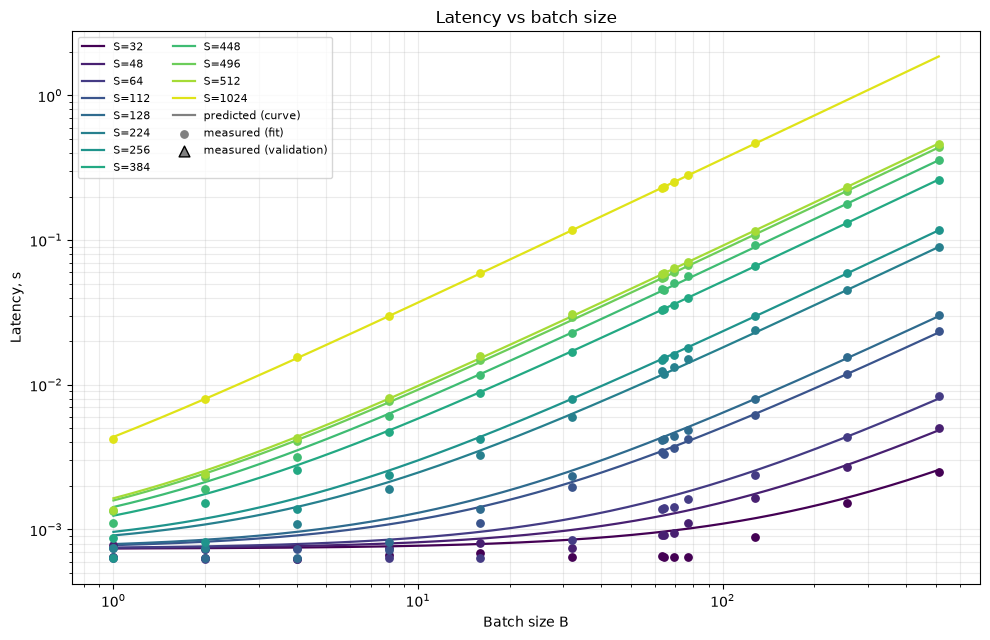

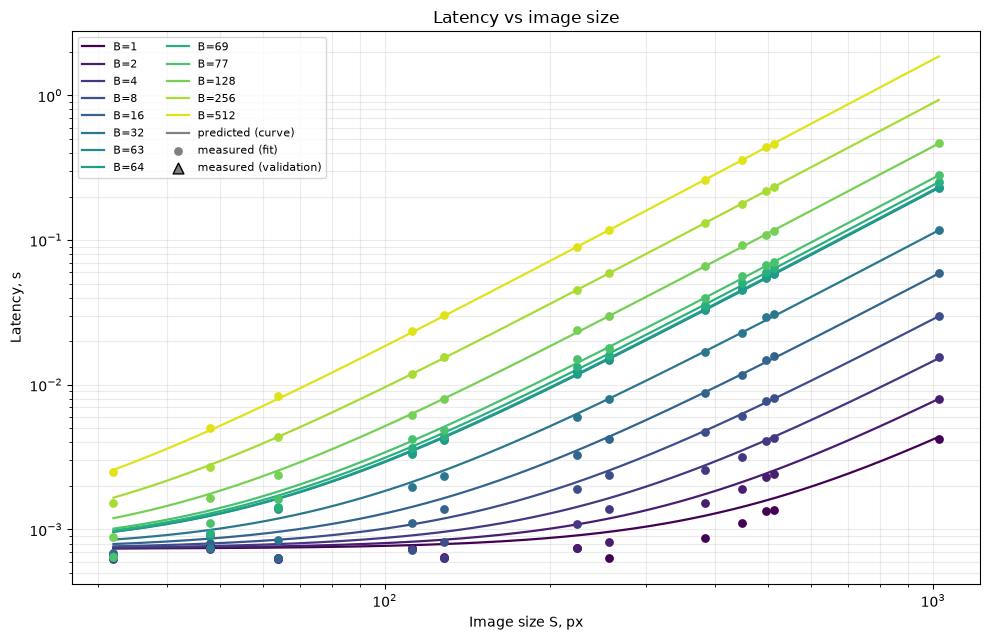

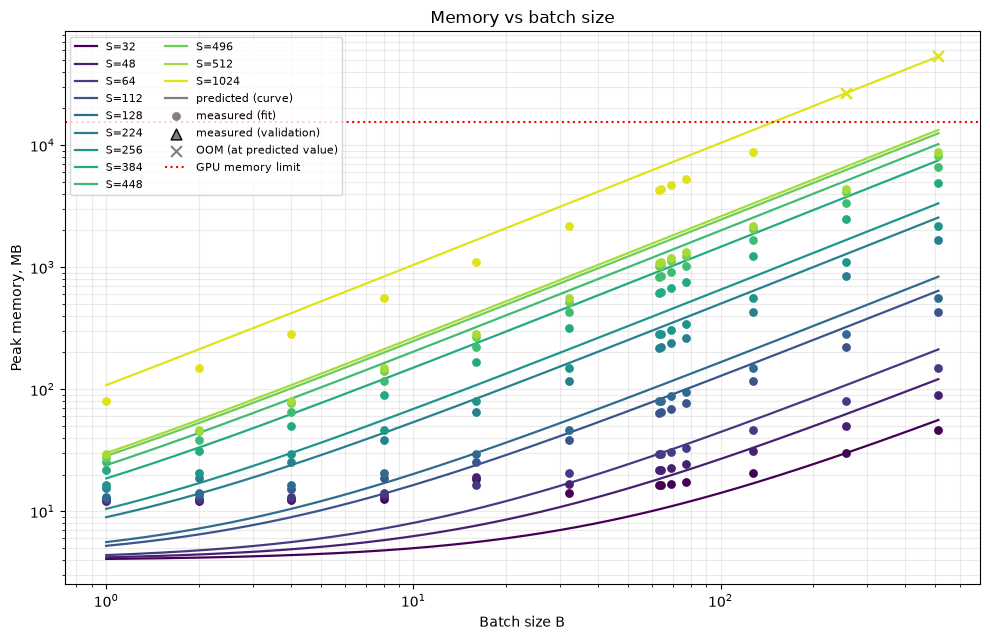

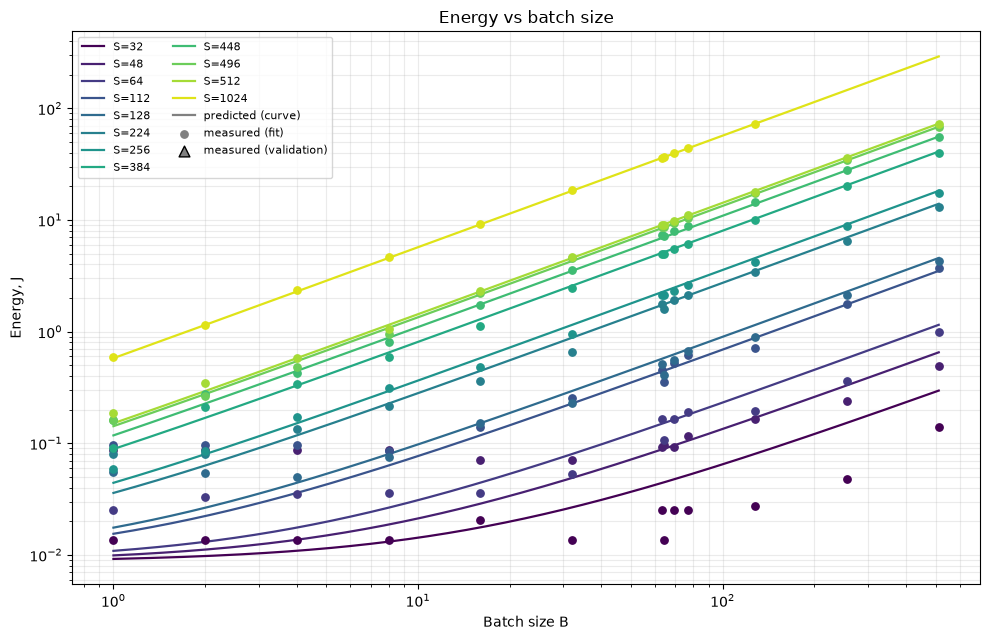

In [17]:
plot_vs_variable(df, "latency", lambda S, B: latency(S, B, theta_latency),
                 "Latency, s", "Latency vs batch size", "latency_vs_B.png", x_var="B")
plot_vs_variable(df, "latency", lambda S, B: latency(S, B, theta_latency),
                 "Latency, s", "Latency vs image size", "latency_vs_S.png", x_var="S")

plot_vs_variable(df, "memory, mb", lambda S, B: memory(S, B) / 2**20,
                 "Peak memory, MB", "Memory vs batch size", "memory_vs_B.png",
                 x_var="B", mark_oom=True, gpu_limit=15 * 1024)

plot_vs_variable(df, "energy", lambda S, B: energy(S, B, theta_latency, theta_energy),
                 "Energy, J", "Energy vs batch size", "energy_vs_B.png", x_var="B")

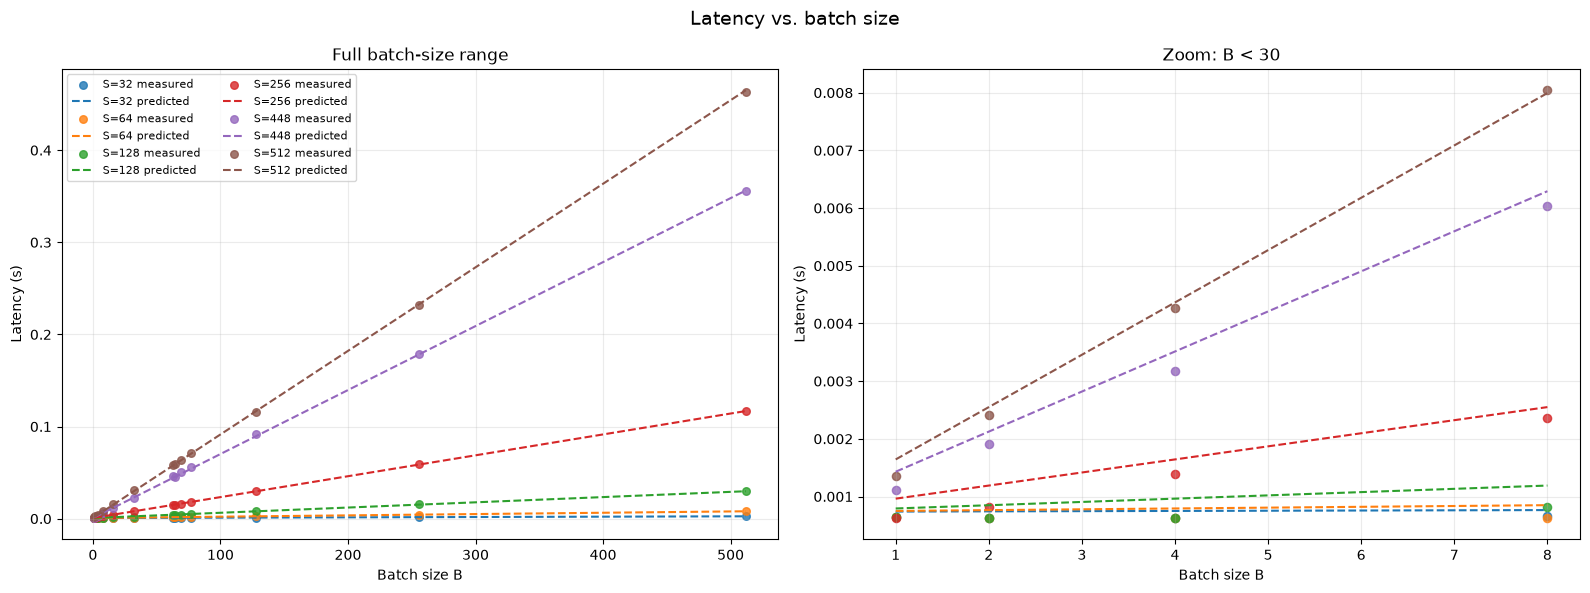

In [12]:
plot_vs_batch(
    df=df,
    measured_column="latency",
    predicted_column="latency_calculated",
    ylabel="Latency (s)",
    title="Latency vs. batch size",
    filename="latency_vs_batch.png",
)

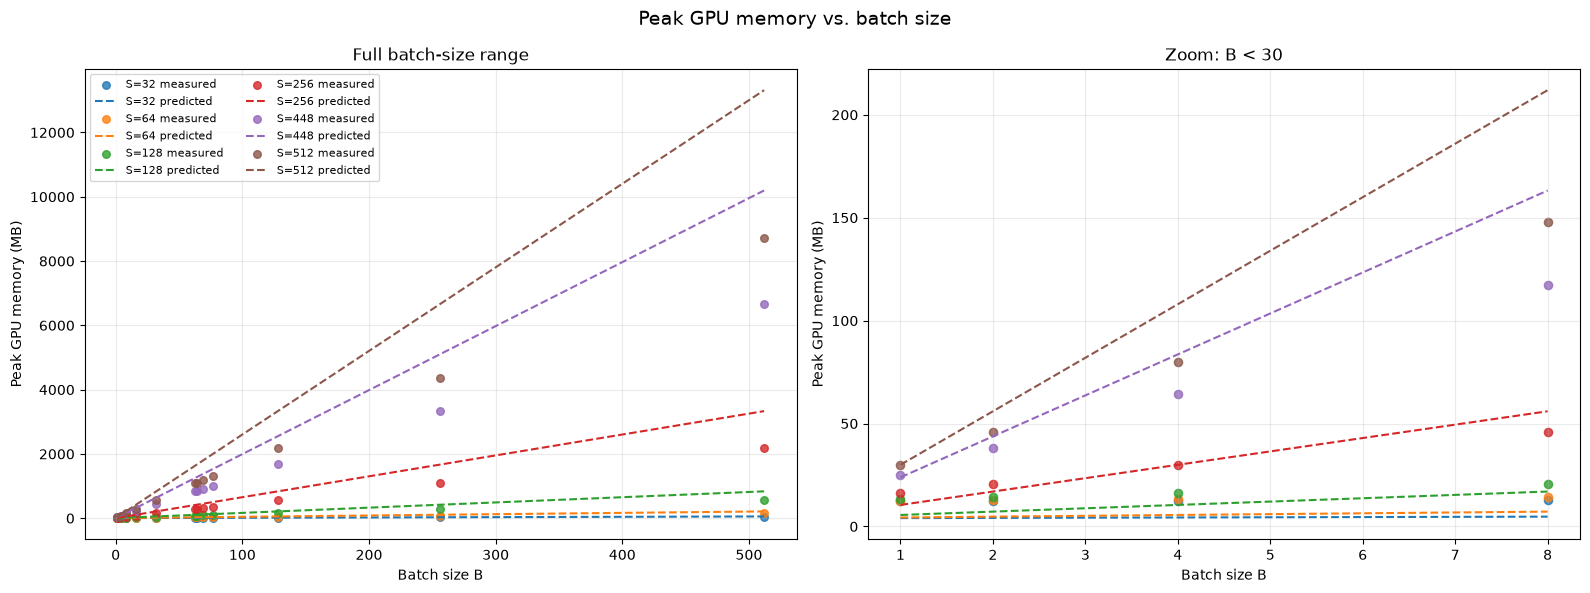

In [13]:
plot_vs_batch(
    df=df,
    measured_column="memory, mb",
    predicted_column="memory_calculated, mb",
    ylabel="Peak GPU memory (MB)",
    title="Peak GPU memory vs. batch size",
    filename="memory_vs_batch.png",
)

#### Видно, что на маленьких значениях image_size и batch_size, поссчитанная оценка ниже, чем фактическое; и напротив, для больших значений -- значение оценки значительно выше.

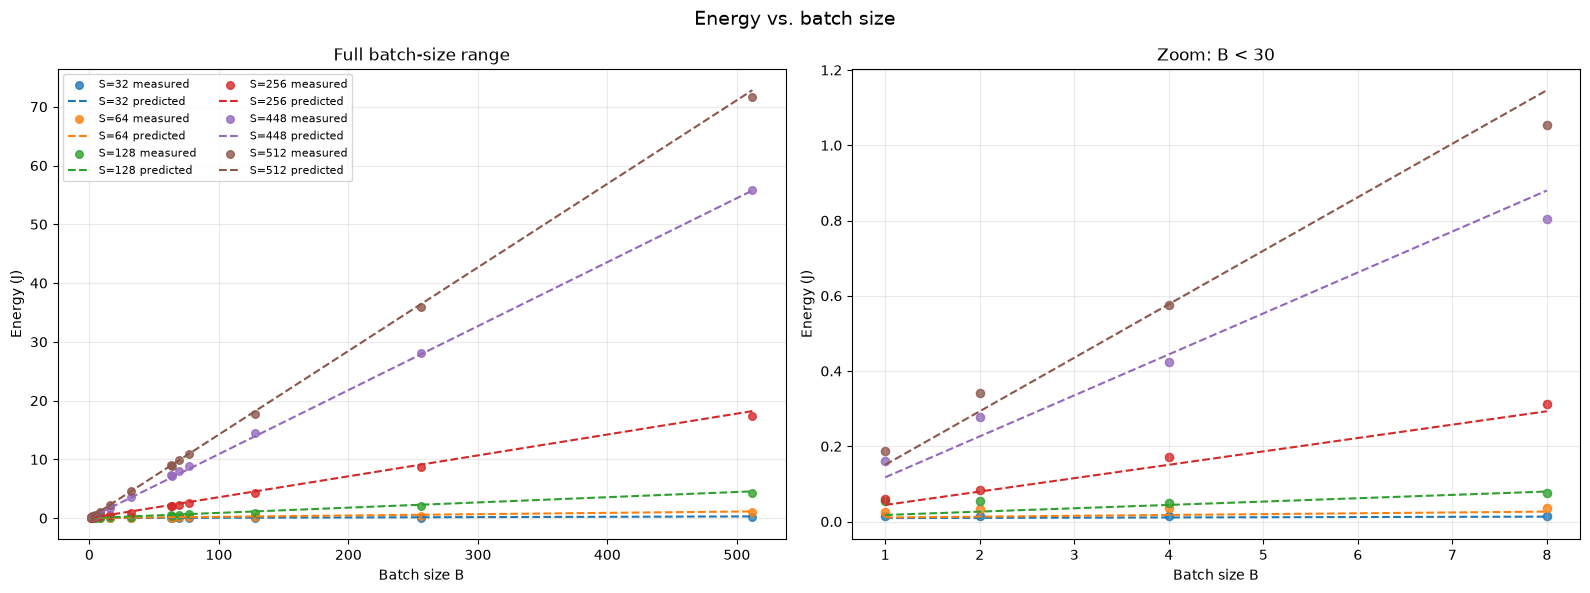

In [14]:
plot_vs_batch(
    df=df,
    measured_column="energy",
    predicted_column="energy_calculated",
    ylabel="Energy (J)",
    title="Energy vs. batch size",
    filename="energy_vs_batch.png",
)